In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
ruta = r"C:\Users\Home\Desktop\proyecto-ciencia-de-datos\data\Connacionales_inscritos_en_el_Registro_Ciudadano_en_Línea_20260514.xlsx"

df = pd.read_excel(ruta)

In [ ]:
# Ver primeras filas
print(df.head())
print("------------------------------")

# Ver información general
print("Información General")
print(df.info())
print("------------------------------")

# Ver dimensiones
print("Dimension del dataset")
print(df.shape)
print("------------------------------")

# Ver datos nulos
print("Datos Nulos: ")
print(df.isnull().sum()) # Datos nulos = 35
print("------------------------------")

# Ver datos Duplicados
print("Datos Duplicados: ")
print(df.duplicated().sum()) # Duplicados = 0
print("------------------------------")
# No hay Datos Duplicados

         País Código ISO país      Ciudad de Residencia  \
0  AFGANISTAN             AFG  BADAKHSHAN/BARREH BARREH   
1  AFGANISTAN             AFG          BADAKHSHAN/BUCHI   
2  AFGANISTAN             AFG               KABOL/KABUL   
3  AFGANISTAN             AFG               KABOL/KABUL   
4  AFGANISTAN             AFG               KABOL/KABUL   

  Oficina de circunscripción consular  Edad (años)  \
0                      C. NUEVA DELHI           25   
1                      C. NUEVA DELHI           37   
2                      C. NUEVA DELHI           34   
3                      C. NUEVA DELHI           35   
4                      C. NUEVA DELHI           45   

                              Área Conocimiento  Nivel Académico Estado civil  \
0                                       NINGUNA     BACHILLERATO      SOLTERO   
1  ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES  SIN INFORMACIÓN  DESCONOCIDO   
2   CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN         MAESTRÍA      SOLTERO

In [5]:
# Eliminamos columnas Inutiles
columnas_eliminar = [
    "Código ISO país",
    "Localización",
    "Fecha de Registro"
]

df = df.drop(columns=columnas_eliminar)

print("Verificamos que si eliminamos las columnas inutiles")
print(df.columns)
print("------------------------------")

# Verificamos dimensiones Antes de Limpieza
print(df.shape)
print("------------------------------")

Verificamos que si eliminamos las columnas inutiles
Index(['País', 'Ciudad de Residencia', 'Oficina de circunscripción consular',
       'Edad (años)', 'Área Conocimiento', 'Nivel Académico', 'Estado civil',
       'Sexo', 'Pertenencia étnica', 'Ciudad de Nacimiento',
       'Cantidad de personas'],
      dtype='str')
------------------------------
(1833558, 11)
------------------------------


In [6]:
# Verificamos balance de la variable
print(df["Área Conocimiento"].value_counts())
print("------------------------------")

Área Conocimiento
NINGUNA                                                  981297
NO INDICA                                                226811
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             152037
INGENIERÍA, ARQUITECTURA Y AFINES                        120974
CIENCIAS DE LA SALUD                                      82161
CIENCIAS SOCIALES Y HUMANAS                               75423
BELLAS ARTES                                              35006
CIENCIAS DE LA EDUCACIÓN                                  33525
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                      28956
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                      19856
SALUD Y BIENESTAR                                         16237
MATEMÁTICAS Y CIENCIAS NATURALES                          12059
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN                9792
EDUCACIÓN                                                  6329
ARTES Y HUMANIDADES                                        6136
COCINA Y CULINARIA    

In [7]:
# existen demasiados datos clasificados como ninguno, no indica y no aplica
categorias_invalidas = [
    "NINGUNA",
    "NO INDICA",
    "(NO REGISTRA)"
]

df = df[~df["Área Conocimiento"].isin(categorias_invalidas)]

# Verificamos de nuevo balance de clases sin datos que no contengan nada
print(df["Área Conocimiento"].value_counts())
print("------------------------------\n")
print("Despues de limpieza: ", df.shape)

Área Conocimiento
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             152037
INGENIERÍA, ARQUITECTURA Y AFINES                        120974
CIENCIAS DE LA SALUD                                      82161
CIENCIAS SOCIALES Y HUMANAS                               75423
BELLAS ARTES                                              35006
CIENCIAS DE LA EDUCACIÓN                                  33525
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                      28956
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                      19856
SALUD Y BIENESTAR                                         16237
MATEMÁTICAS Y CIENCIAS NATURALES                          12059
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN                9792
EDUCACIÓN                                                  6329
ARTES Y HUMANIDADES                                        6136
COCINA Y CULINARIA                                         5019
AGRONOMÍA, VETERINARIA Y AFINES                            5016
AGRONOMÍA, VETERINARIA

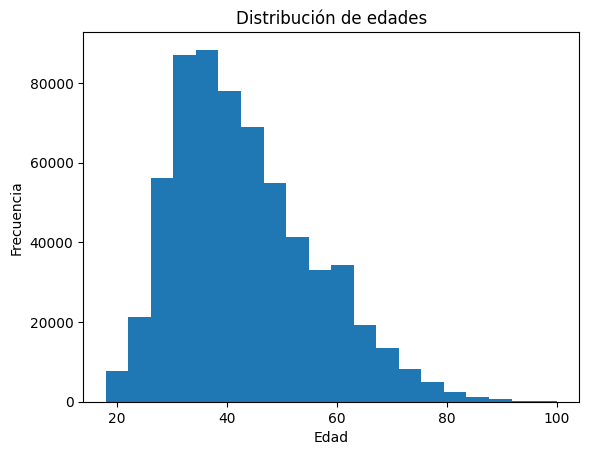

In [8]:
# Filtrar edades validas 
df = df[
    (df["Edad (años)"] >= 18) &
    (df["Edad (años)"] <= 100)
    ]

#Verificamos datos de edad
plt.hist(df["Edad (años)"], bins=20)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

In [9]:
# Revision de dimensiones despues de limpieza logica para verificar que no existen variables de tipo [Maestia, MAESTRIA, maestria]

print("------------------------------")
print(df["Nivel Académico"].unique())
print("------------------------------")
print(df["Sexo"].unique())
print("------------------------------")
print(df["Estado civil"].unique())
print("------------------------------")
print(df["Área Conocimiento"].unique())
print("------------------------------")



------------------------------
<StringArray>
[    'SIN INFORMACIÓN',            'MAESTRÍA',         'PROFESIONAL',
 'TÉCNICA PROFESIONAL',     'ESPECIALIZACIÓN',         'TECNOLÓGICA',
        'BACHILLERATO',           'DOCTORADO',             'NINGUNO',
       'UNIVERSITARIA',            'PRIMARIA']
Length: 11, dtype: str
------------------------------
<StringArray>
['FEMENINO', 'MASCULINO', 'DESCONOCIDO', 'NO_BINARIO']
Length: 4, dtype: str
------------------------------
<StringArray>
[         'DESCONOCIDO',              'SOLTERO',               'CASADO',
          'UNION_LIBRE',           'DIVORCIADO',                'VIUDO',
  'SEPARADO_MATRIMONIO', 'SEPARADO_UNION_LIBRE']
Length: 8, dtype: str
------------------------------
<StringArray>
[         'ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES',
           'CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN',
                           'CIENCIAS SOCIALES Y HUMANAS',
                                     'SALUD Y BIENESTAR',
              

In [10]:

# Debido al desbalance de clases del dataset, además de accuracy se utilizaran métricas como precision, recall y F1-score para evaluar el desempeño real del modelo.

# Aplicamos variables
X = df[
    [
        "País",
        "Edad (años)",
        "Nivel Académico",
        "Sexo",
        "Estado civil"
    ]
]

Y = df["Área Conocimiento"]

# Aplicamos one hot encoding
X = pd.get_dummies(X)
print("------------------------------")
print(X.shape)
print("------------------------------")

------------------------------
(622008, 210)
------------------------------


In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [14]:
#verificamos dimensiones
print(X_train.shape)
print(X_test.shape)

(497606, 210)
(124402, 210)


In [ ]:
# Creamos modelo de regresion logistica
modelo_log = LogisticRegression(
    max_iter = 1000
)

# entrenamos el modelo
modelo_log.fit(X_train,Y_train)

# hacemos predicciones
pred_log = modelo_log.predict(X_test)

# Hacemos evaluacion
print("=== REGRESIÓN LOGÍSTICA ===")

print(
    "Accuracy:",
    accuracy_score(Y_test, pred_log)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        pred_log,
        average="weighted",
        zero_division = 0
)
)

print(
    "Recall:",
    recall_score(
        Y_test,
        pred_log,
        average="weighted",
        zero_division = 0
    )
)

print(
    "F1-score:",
    f1_score(
        Y_test,
        pred_log,
        average="weighted",
        zero_division = 0
    )
)

c:\Users\Home\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== REGRESIÓN LOGÍSTICA ===
Accuracy: 0.2906062603495121


c:\Users\Home\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision: 0.2537406384362354
Recall: 0.2906062603495121
F1-score: 0.20487671222753098


Accuracy: 29.06%
Precision: 25.37%
Recall: 29.06%
F1-score: 20.48%

La Regresion Logistica probablemente

* favoreció clases grandes
* ignoró clases pequeñas

A demas **presentó limitaciones** debido al carácter multiclase y no linealidad del problema, además del desbalance de categorías.

In [21]:
# Creamos el modelo de Arbol
modelo_tree = DecisionTreeClassifier(
    random_state=42
)

#Entrenamos
modelo_tree.fit(X_train, Y_train)

# Aplicamos predicciones 
pred_tree = modelo_tree.predict(X_test)

print("=== ÁRBOL DE DECISIÓN ===")

print(
    "Accuracy:",
    accuracy_score(Y_test, pred_tree)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        pred_tree,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        pred_tree,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1-score:",
    f1_score(
        Y_test,
        pred_tree,
        average="weighted",
        zero_division=0
    )
)

=== ÁRBOL DE DECISIÓN ===
Accuracy: 0.25755212938698735
Precision: 0.20851841775387786
Recall: 0.25755212938698735
F1-score: 0.2175776686928871


Accuracy: 25.75%
Precision: 20.85%
Recall: 25.75%
F1-score: 21.75%

El F1-score es relativamente bajo.

Eso indica que:

* el árbol está teniendo dificultades
* posiblemente hay overfitting
* algunas clases no se distinguen bien

Los modelos base **presentaron limitaciones** debido al desbalance y complejidad multiclase del dataset

In [27]:
modelo_rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

modelo_rf.fit(X_train, Y_train)

pred_rf = modelo_rf.predict(X_test)

print("=== RANDOM FOREST ===")

print(
    "Accuracy:",
    accuracy_score(Y_test, pred_rf)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        pred_rf,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        pred_rf,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1-score:",
    f1_score(
        Y_test,
        pred_rf,
        average="weighted",
        zero_division=0
    )
)

=== RANDOM FOREST ===
Accuracy: 0.26273693348981525
Precision: 0.20950164958144196
Recall: 0.26273693348981525
F1-score: 0.21795800272797763


Durante el desarrollo del proyecto se identificó que el enfoque inicial orientado a predecir el área de conocimiento presentaba limitaciones importantes debido al alto solapamiento entre categorías, el desbalance de clases y la baja capacidad predictiva de las variables disponibles. A partir de los resultados obtenidos en los modelos de clasificación, se decidió replantear la metodología hacia un análisis de patrones migratorios y tendencias académicas, permitiendo un estudio más coherente y alineado con la naturaleza real del dataset.

# Pregunta principal
¿Qué áreas de conocimiento presentan mayor migración internacional entre los colombianos registrados en el exterior?

## Preguntas secundarias
* ¿Qué perfiles académicos presentan mayor movilidad internacional?
* ¿Qué países concentran determinadas áreas de conocimiento?
* ¿Qué rango de edad predomina según el área académica?
* ¿Existe relación entre nivel académico y migración internacional?
* ¿Qué características sociodemográficas predominan en los perfiles migratorios?

In [ ]:
# realizamos conteo de áreas de conocimiento
areas = df["Área Conocimiento"].value_counts()

print(areas)

Área Conocimiento
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             151304
INGENIERÍA, ARQUITECTURA Y AFINES                        120524
CIENCIAS DE LA SALUD                                      81778
CIENCIAS SOCIALES Y HUMANAS                               75152
BELLAS ARTES                                              34901
CIENCIAS DE LA EDUCACIÓN                                  33337
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                      28827
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                      19778
SALUD Y BIENESTAR                                         16162
MATEMÁTICAS Y CIENCIAS NATURALES                          12003
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN                9766
EDUCACIÓN                                                  6285
ARTES Y HUMANIDADES                                        6115
COCINA Y CULINARIA                                         4997
AGRONOMÍA, VETERINARIA Y AFINES                            4981
AGRONOMÍA, VETERINARIA

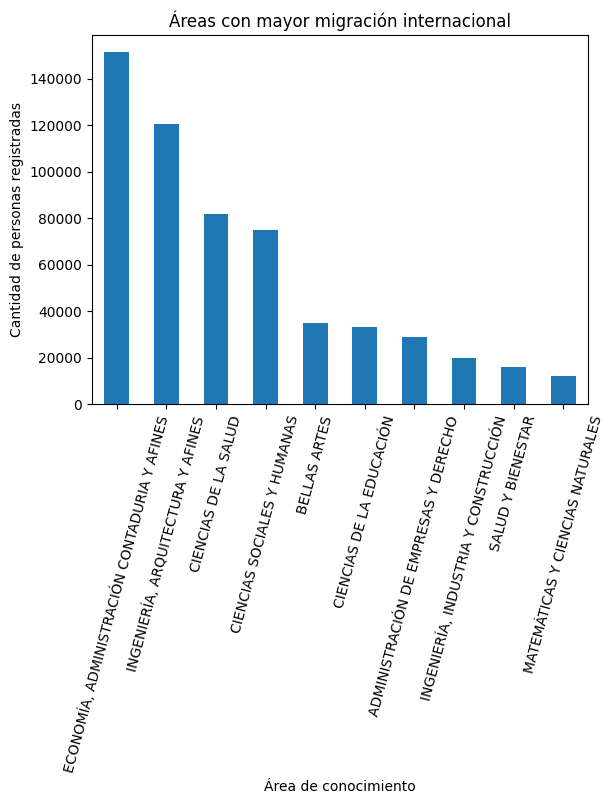

In [31]:
# Grafica de las areas mas representativas
areas.head(10).plot(kind="bar")

plt.title("Áreas con mayor migración internacional")
plt.xlabel("Área de conocimiento")
plt.ylabel("Cantidad de personas registradas")

plt.xticks(rotation=75)

plt.show()

In [ ]:
# Revisamos Valores de Nivel Academico
df["Nivel Académico"].value_counts()

Nivel Académico
SIN INFORMACIÓN        262105
PROFESIONAL            176870
TÉCNICA PROFESIONAL     69958
MAESTRÍA                40933
TECNOLÓGICA             36213
ESPECIALIZACIÓN         24669
DOCTORADO                8204
BACHILLERATO             2372
NINGUNO                   475
PRIMARIA                  190
UNIVERSITARIA              19
Name: count, dtype: int64

Al revisar el Dataset se eliminaran datos sin informacion y la seccion UNIVERSITARIA debido a que es semanticamente parecida a profesional, ademas de tener muy pocos datos

se decidio no eliminar datos de primaria debido a que los Colombianos puede tener formación técnica en
* cursos complementarios
* experiencia laboral
* formación no universitaria

sin necesariamente haber terminado bachillerato formalmente y que concuerdan con las pocas carreras que se encontraron vinculadas a esta sección.


In [36]:
niveles_invalidos = [
    "SIN INFORMACIÓN",
    "NINGUNO",
    "UNIVERSITARIA"
]

df = df[
    ~df["Nivel Académico"].isin(niveles_invalidos)
]

print(df["Nivel Académico"].value_counts())
# Verificamos el registro de datos
print(df.shape)
df["Área Conocimiento"].value_counts()

Nivel Académico
PROFESIONAL            176870
TÉCNICA PROFESIONAL     69958
MAESTRÍA                40933
TECNOLÓGICA             36213
ESPECIALIZACIÓN         24669
DOCTORADO                8204
BACHILLERATO             2372
PRIMARIA                  190
Name: count, dtype: int64
(359409, 11)


Área Conocimiento
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             75404
INGENIERÍA, ARQUITECTURA Y AFINES                        59455
CIENCIAS DE LA SALUD                                     40742
CIENCIAS SOCIALES Y HUMANAS                              36782
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                     28772
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                     19750
BELLAS ARTES                                             16800
SALUD Y BIENESTAR                                        16135
CIENCIAS DE LA EDUCACIÓN                                 15594
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN               9745
EDUCACIÓN                                                 6273
ARTES Y HUMANIDADES                                       6104
MATEMÁTICAS Y CIENCIAS NATURALES                          5896
COCINA Y CULINARIA                                        4990
AGRONOMÍA, VETERINARIA Y ZOOTECNIA                        3610
TECNOLOGÍAS DE LA INFORMACIÓN Y LA CO

Aunque el número de registros se redujo considerablemente durante la depuración, esto permitió trabajar con perfiles académicos consistentes y relevantes para el análisis migratorio, eliminando registros incompletos o sin valor analítico.

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "País",
        "Nivel Académico",
        "Sexo",
        "Estado civil"
    ],
    drop_first=True
)

A partir de ahora se empieza con EDA y analisis de tendencias

In [37]:
# realizamos conteo de áreas de conocimiento
areas = df["Área Conocimiento"].value_counts()

print(areas)

Área Conocimiento
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             75404
INGENIERÍA, ARQUITECTURA Y AFINES                        59455
CIENCIAS DE LA SALUD                                     40742
CIENCIAS SOCIALES Y HUMANAS                              36782
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                     28772
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                     19750
BELLAS ARTES                                             16800
SALUD Y BIENESTAR                                        16135
CIENCIAS DE LA EDUCACIÓN                                 15594
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN               9745
EDUCACIÓN                                                 6273
ARTES Y HUMANIDADES                                       6104
MATEMÁTICAS Y CIENCIAS NATURALES                          5896
COCINA Y CULINARIA                                        4990
AGRONOMÍA, VETERINARIA Y ZOOTECNIA                        3610
TECNOLOGÍAS DE LA INFORMACIÓN Y LA CO

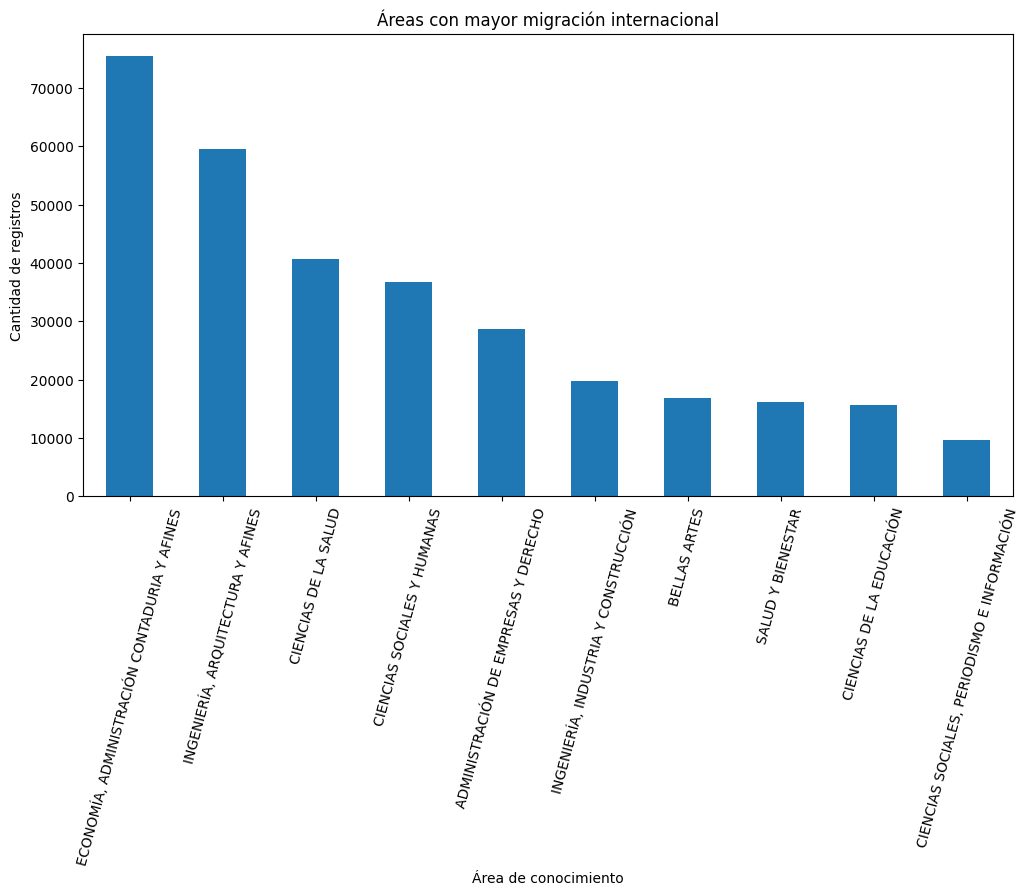

In [38]:
areas.head(10).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Áreas con mayor migración internacional")
plt.xlabel("Área de conocimiento")
plt.ylabel("Cantidad de registros")

plt.xticks(rotation=75)

plt.show()

Las áreas relacionadas con ingeniería, economía y salud presentan la mayor cantidad de registros migratorios, lo que sugiere una alta movilidad internacional de perfiles técnicos y profesionales.

In [39]:
niveles = df["Nivel Académico"].value_counts()

print(niveles)

Nivel Académico
PROFESIONAL            176870
TÉCNICA PROFESIONAL     69958
MAESTRÍA                40933
TECNOLÓGICA             36213
ESPECIALIZACIÓN         24669
DOCTORADO                8204
BACHILLERATO             2372
PRIMARIA                  190
Name: count, dtype: int64


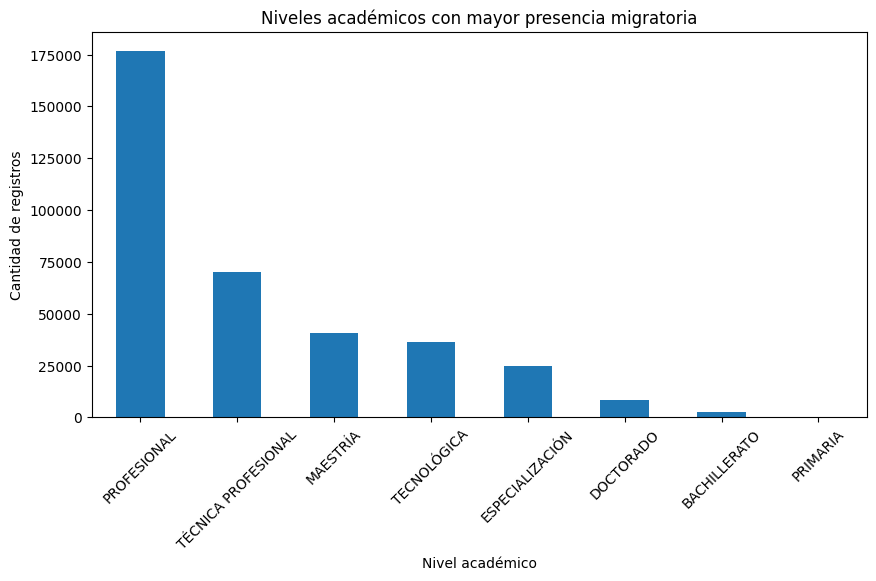

In [40]:
niveles.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Niveles académicos con mayor presencia migratoria")
plt.xlabel("Nivel académico")
plt.ylabel("Cantidad de registros")

plt.xticks(rotation=45)

plt.show()

In [41]:
# Relación Área <-> Nivel Académico
cruce_area_nivel = pd.crosstab(
    df["Área Conocimiento"],
    df["Nivel Académico"]
)

print(cruce_area_nivel)

Nivel Académico                                     BACHILLERATO  DOCTORADO  \
Área Conocimiento                                                             
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                           0        173   
AGRONOMÍA, VETERINARIA Y AFINES                               39         31   
AGRONOMÍA, VETERINARIA Y ZOOTECNIA                             0        161   
AGROPECUARIO, SILVICULTURA, PESCA, Y VETERINARIA               0         67   
ARTES Y HUMANIDADES                                            2         80   
AVIACIÓN                                                       0          7   
BELLAS ARTES                                                 208        122   
CIENCIAS DE LA EDUCACIÓN                                     156        266   
CIENCIAS DE LA SALUD                                         390       1139   
CIENCIAS NATURALES, MATEMÁTICAS Y ESTADÍSTICA                  0        496   
CIENCIAS SOCIALES Y HUMANAS                         

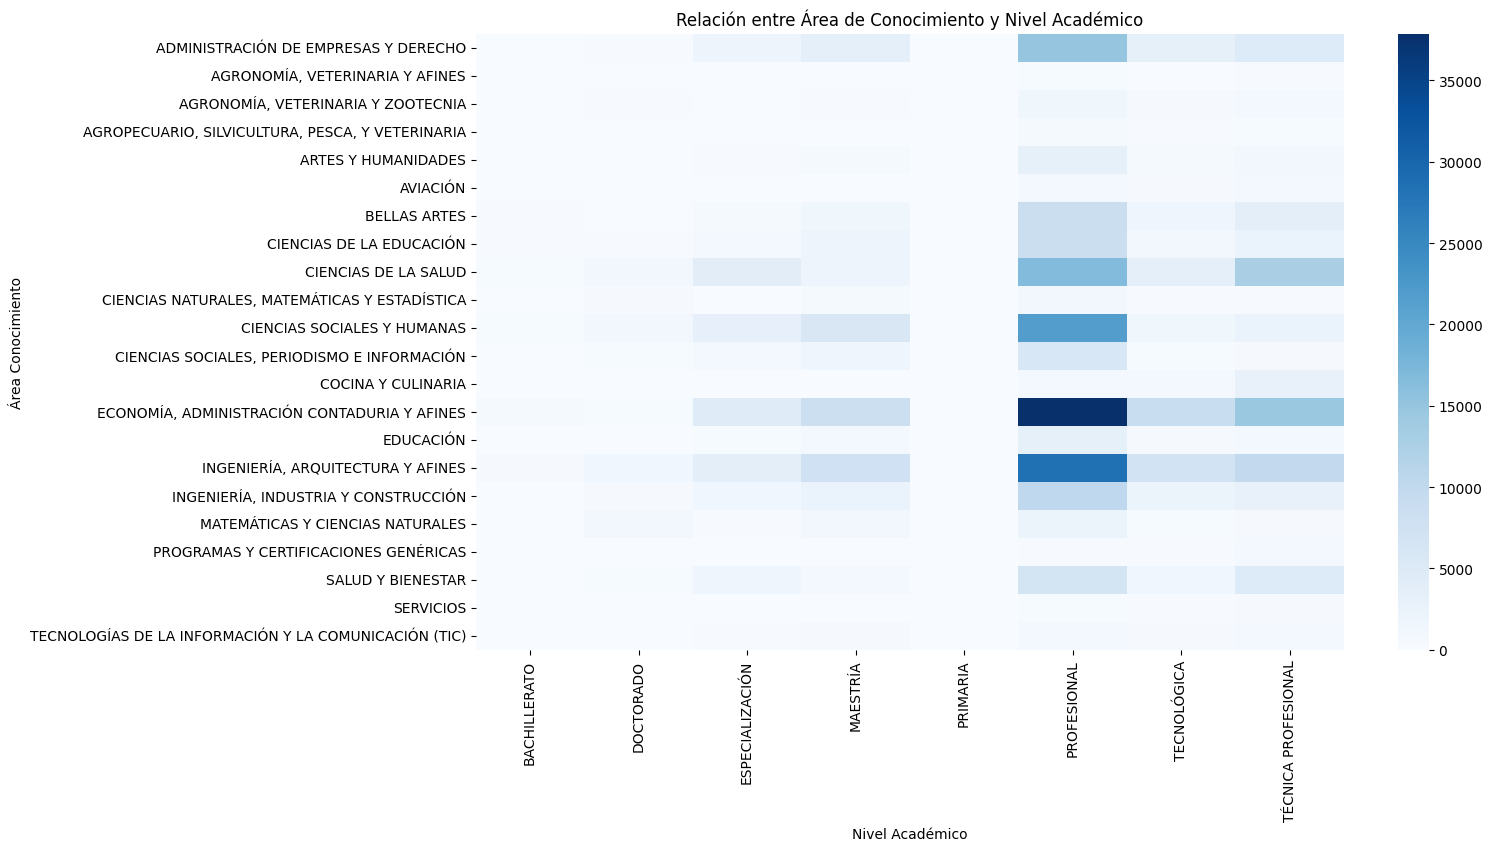

In [43]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cruce_area_nivel,
    cmap="Blues"
)

plt.title("Relación entre Área de Conocimiento y Nivel Académico")

plt.show()

Aquí se puede descubrir:

* áreas con mayor nivel profesional
* áreas con más maestrías
* áreas con menor formación avanzada
* concentración académica

In [44]:
# Cruce País <-> Aera
cruce_pais_area = pd.crosstab(
    df["País"],
    df["Área Conocimiento"]
)

print(cruce_pais_area)

Área Conocimiento  ADMINISTRACIÓN DE EMPRESAS Y DERECHO  \
País                                                      
AFGANISTAN                                            0   
ALBANIA                                               0   
ALEMANIA                                            440   
ANDORRA                                              34   
ANGOLA                                                2   
...                                                 ...   
VANUATU                                               0   
VENEZUELA                                           922   
VIET NAM                                              3   
VIETNAM                                               0   
YEMEN                                                 0   

Área Conocimiento  AGRONOMÍA, VETERINARIA Y AFINES  \
País                                                 
AFGANISTAN                                       0   
ALBANIA                                          0   
ALEMANIA        

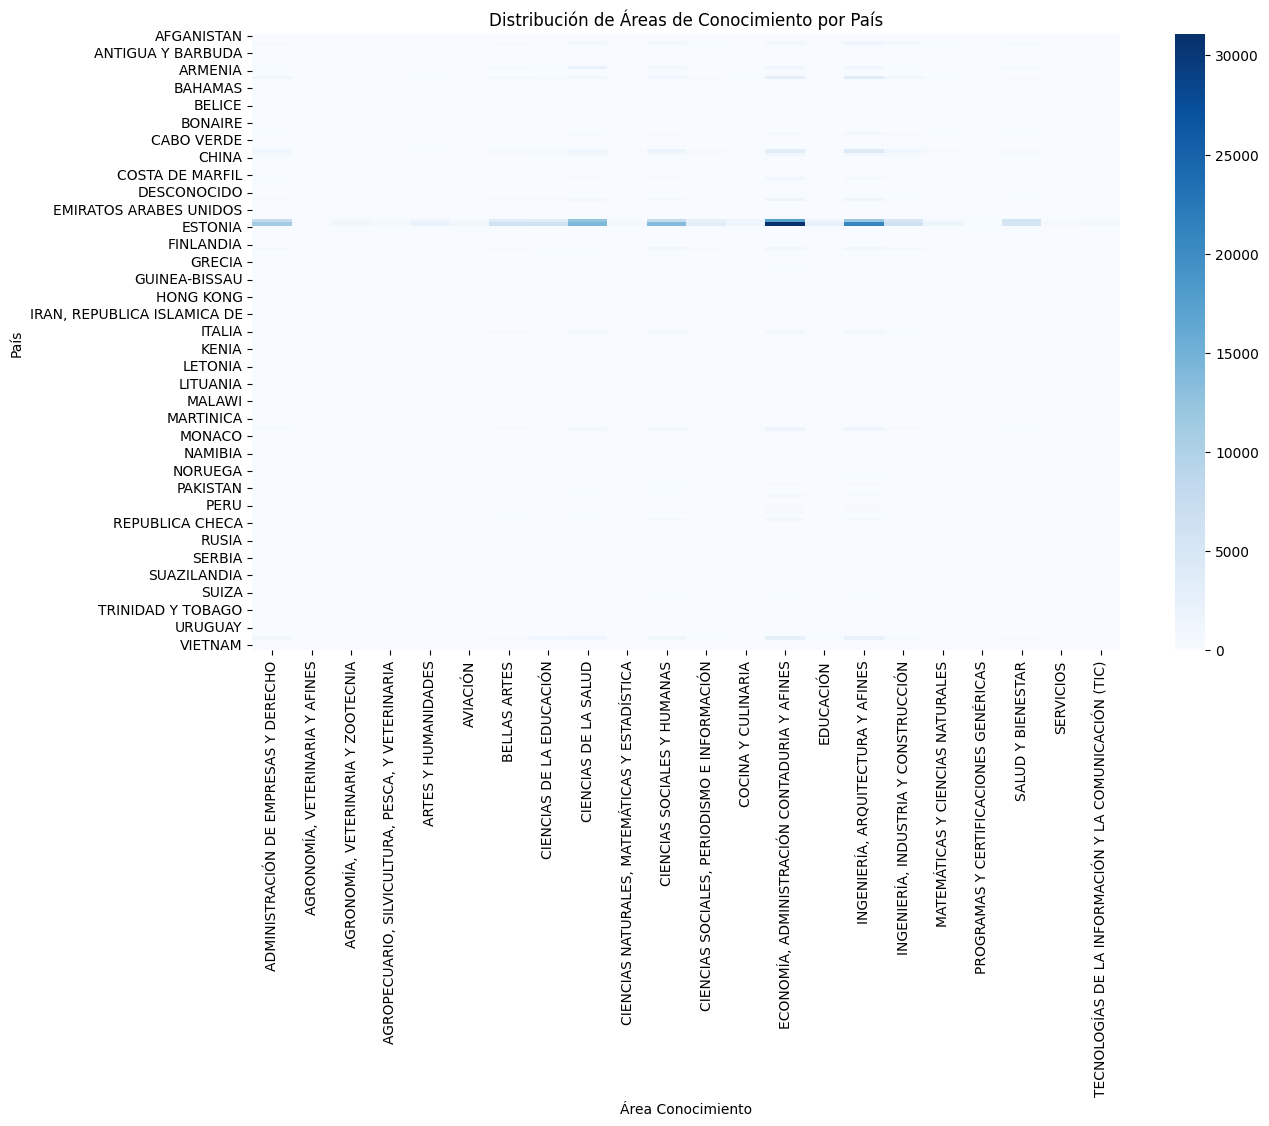

In [47]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cruce_pais_area,
    cmap="Blues"
)

plt.title("Distribución de Áreas de Conocimiento por País")

plt.show()

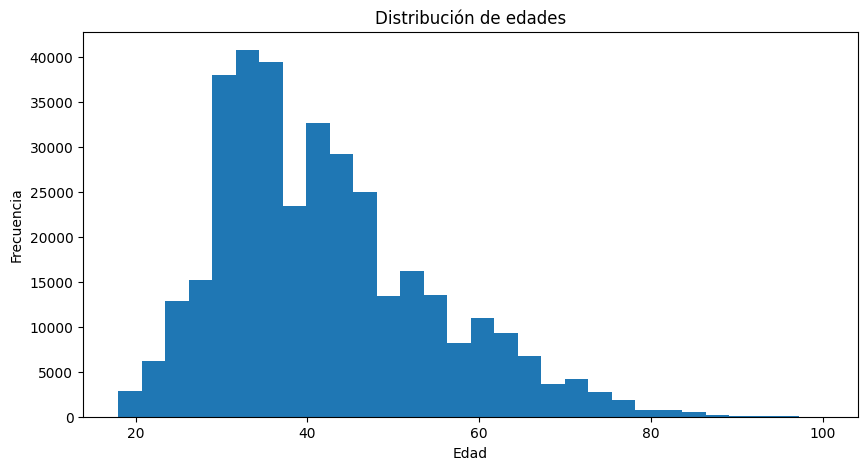

Media: 41.93764485586059
Mediana: 40.0
Moda: 33


In [49]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Edad (años)"],
    bins=30
)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

print(
    "Media:",
    df["Edad (años)"].mean()
)

print(
    "Mediana:",
    df["Edad (años)"].median()
)

print(
    "Moda:",
    df["Edad (años)"].mode()[0]
)

En esta grafica se puede ver:

* edades predominantes: 30 -> 35
* población joven vs adulta
* edades con mayor movilidad internacional

La población migrante presenta una concentración importante en adultos jóvenes, observándose edades predominantes cercanas a los 30 años.

In [50]:
# Paises con mayor migración
paises = df["País"].value_counts()

print(paises.head(10))

País
ESTADOS UNIDOS    131946
ESPAÑA             86360
CANADA             16954
AUSTRALIA          16183
VENEZUELA          12476
ARGENTINA           9270
MEXICO              7819
FRANCIA             7711
ECUADOR             7679
ALEMANIA            7616
Name: count, dtype: int64


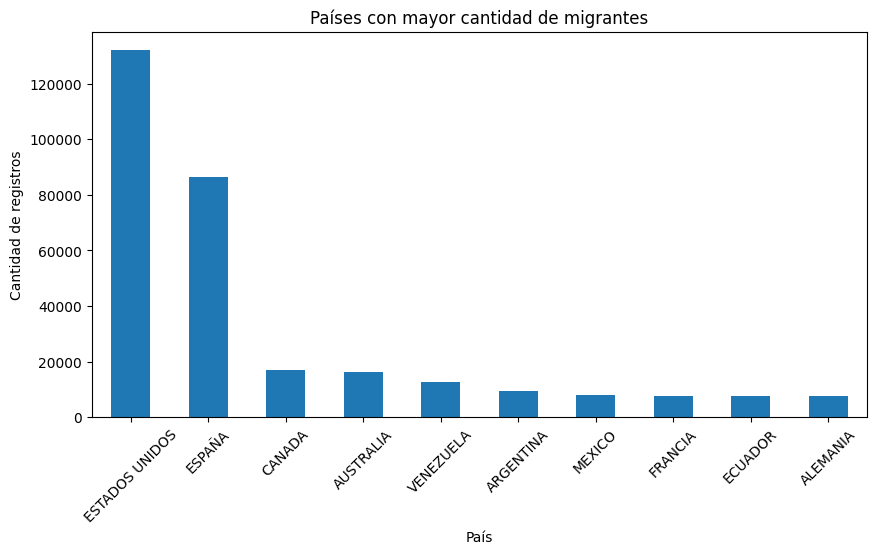

In [51]:
paises.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Países con mayor cantidad de migrantes")
plt.xlabel("País")
plt.ylabel("Cantidad de registros")

plt.xticks(rotation=45)

plt.show()

En esta grafica se puede visualizar la tendencia a los destinos predomintantes y la concentracion migratoria de los Colombianos

In [ ]:
# Analisis Area por pais
top_paises = df["País"].value_counts().head(5).index

# Filtramos dataset
df_top = df[
    df["País"].isin(top_paises)
]

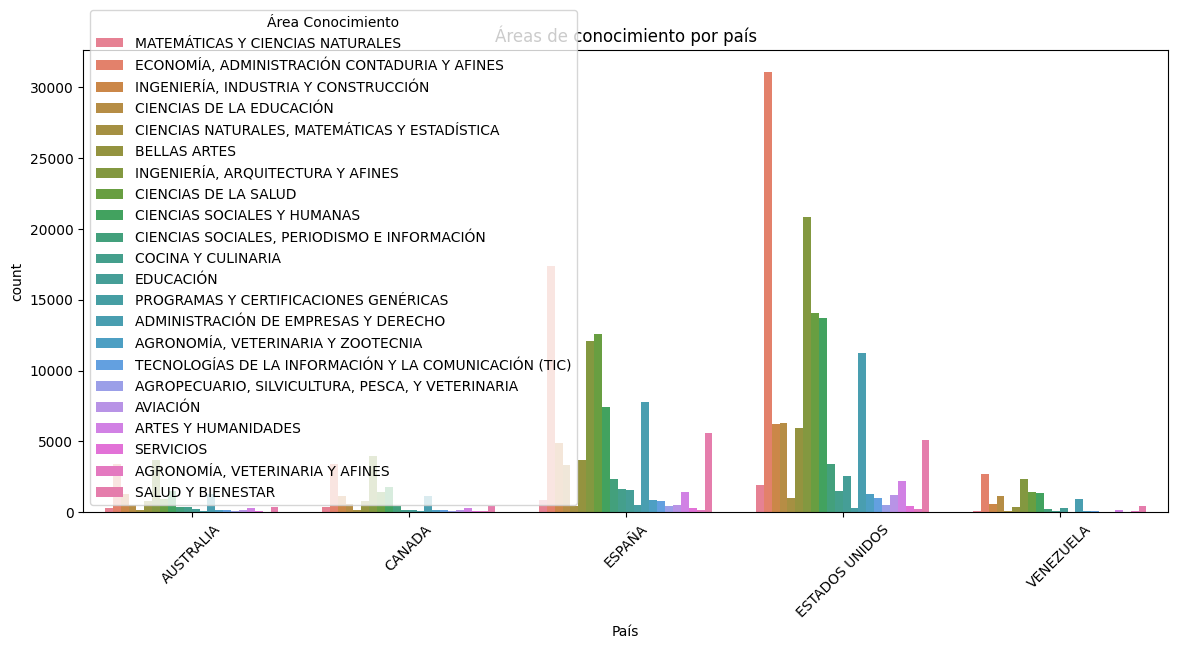

In [54]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df_top,
    x="País",
    hue="Área Conocimiento"
)

plt.title("Áreas de conocimiento por país")

plt.xticks(rotation=45)

plt.show()

¿Qué revela esto?, Aquí se descubre que:

* Canadá atrae más ingeniería
* Estados Unidos más salud
* Australia más técnicas

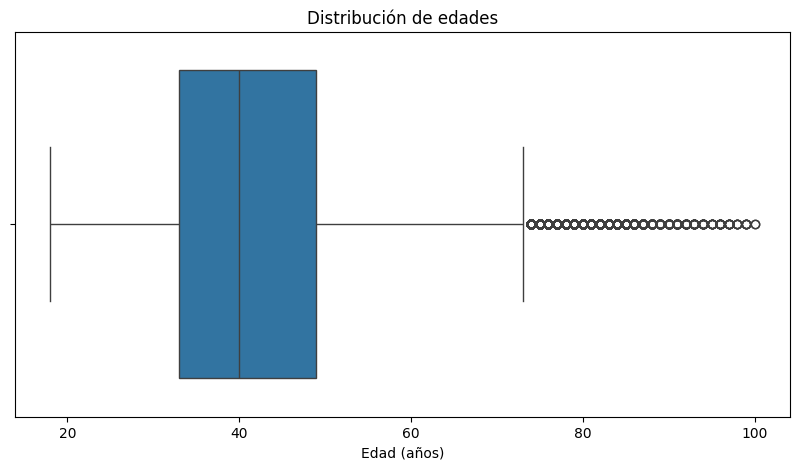

In [ ]:
# BOX-PLOT de edades
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Edad (años)"]
)

plt.title("Distribución de edades")

plt.show()

In [56]:
# Distribuciones porcentuales
porcentaje_areas = (
    df["Área Conocimiento"]
    .value_counts(normalize=True) * 100
)

print(porcentaje_areas)

Área Conocimiento
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             20.979998
INGENIERÍA, ARQUITECTURA Y AFINES                        16.542435
CIENCIAS DE LA SALUD                                     11.335832
CIENCIAS SOCIALES Y HUMANAS                              10.234023
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                      8.005364
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                      5.495132
BELLAS ARTES                                              4.674340
SALUD Y BIENESTAR                                         4.489314
CIENCIAS DE LA EDUCACIÓN                                  4.338790
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN               2.711396
EDUCACIÓN                                                 1.745365
ARTES Y HUMANIDADES                                       1.698344
MATEMÁTICAS Y CIENCIAS NATURALES                          1.640471
COCINA Y CULINARIA                                        1.388390
AGRONOMÍA, VETERINARIA Y ZOOTECNIA          

El **20.97%** de los registros corresponde a áreas de **Economia, administracón, contaduria y afines**, esto muestra una predominanca en esa carrera para migrar por trabajo.

# Conclusión EDA

El análisis exploratorio permitió identificar patrones relevantes en la movilidad internacional de colombianos registrados en el exterior, especialmente en relación con las áreas de conocimiento y los perfiles académicos predominantes. Durante el proceso de depuración se detectaron inconsistencias, categorías ambiguas y registros sin información útil, por lo que se realizó una limpieza orientada a conservar únicamente datos relevantes para el análisis académico y migratorio.

Los resultados evidenciaron que las áreas relacionadas con ingeniería, economía, salud y ciencias sociales concentran la mayor presencia migratoria internacional, lo que sugiere una alta demanda y movilidad de perfiles técnicos y profesionales en estos sectores. Asimismo, se observó que los niveles académicos con mayor representación corresponden principalmente a formación profesional, técnica profesional y posgrados, reflejando una tendencia migratoria asociada a perfiles con formación especializada.

En cuanto a las variables sociodemográficas, la distribución de edades mostró una concentración predominante en adultos jóvenes y población económicamente activa, lo cual es coherente con dinámicas migratorias orientadas a oportunidades laborales y académicas en el exterior.

Para los modelos utilizados se utilizara la nueva variable objetivo `País` y las variables predictivas pasaran a ser `Área Conocimiento`, `Nivel Académico`, `Edad`, `Sexo` y `Estado civil`

los modelos intentaran predecir patrones como que perfil academico a lleva a que destino migratorio 

In [58]:
y = df["País"]

X = df[
    [
    "Área Conocimiento",
    "Nivel Académico",
    "Edad (años)",
    "Sexo",
    "Estado civil"
    ]
]

# Hacemos Encoding
X = pd.get_dummies(
    X,
    drop_first=True
)

In [59]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(287527, 39)
(71882, 39)


In [60]:
modelo_log = LogisticRegression(
    max_iter=1000
)

# entrenamos
modelo_log.fit(X_train, y_train)

pred_log = modelo_log.predict(X_test)

print("=== REGRESIÓN LOGÍSTICA ===")

print(
    "Accuracy:",
    accuracy_score(y_test, pred_log)
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_log,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        pred_log,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1-score:",
    f1_score(
        y_test,
        pred_log,
        average="weighted",
        zero_division=0
    )
)

c:\Users\Home\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== REGRESIÓN LOGÍSTICA ===
Accuracy: 0.3961075095295067
Precision: 0.2779076128776064
Recall: 0.3961075095295067
F1-score: 0.2942421099952882


=== REGRESIÓN LOGÍSTICA ===
Accuracy: 39.61%
Precision: 27.79%
Recall: 39.61%
F1-score: 29.42%

El replanteamiento de la variable objetivo permitió mejorar el desempeño de los modelos de clasificación, evidenciando una relación más consistente entre las variables sociodemográficas y el país de destino migratorio.


In [89]:
# Modelo Árbol de Decisión
modelo_tree = DecisionTreeClassifier(
    random_state=42
)

# entrenamos modelo
modelo_tree.fit(X_train, y_train)

pred_tree = modelo_tree.predict(X_test)

print("=== ÁRBOL DE DECISIÓN ===")

print(
    "Accuracy:",
    accuracy_score(y_test, pred_tree)
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_tree,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        pred_tree,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1-score:",
    f1_score(
        y_test,
        pred_tree,
        average="weighted",
        zero_division=0
    )
)

=== ÁRBOL DE DECISIÓN ===
Accuracy: 0.37003700509167803
Precision: 0.31032986077784125
Recall: 0.37003700509167803
F1-score: 0.32196506306462114


In [90]:
#verificamos si hubo overfitting
train_pred_tree = modelo_tree.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    train_pred_tree
)

print(
    "Accuracy entrenamiento:",
    train_accuracy
)

test_accuracy = accuracy_score(
    y_test,
    pred_tree
)

print(
    "Accuracy prueba:",
    test_accuracy
)

Accuracy entrenamiento: 0.4821599362842446
Accuracy prueba: 0.37003700509167803


Incluso utilizando modelos no lineales, la predicción exacta del país destino continúa siendo un problema complejo debido al comportamiento heterogéneo de los perfiles migratorios.

tambien podemos notar que el Árbol de Decisión presentó señales de sobreajuste, evidenciadas por una diferencia considerable entre el rendimiento en entrenamiento y prueba. Esto justificó el uso de modelos ensemble como Random Forest y XGBoost.

In [92]:
# Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

print("=== RANDOM FOREST ===")

print(
    "Accuracy:",
    accuracy_score(y_test, pred_rf)
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_rf,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        pred_rf,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1-score:",
    f1_score(
        y_test,
        pred_rf,
        average="weighted",
        zero_division=0
    )
)

=== RANDOM FOREST ===
Accuracy: 0.40648562922567544
Precision: 0.3527029350980954
Recall: 0.40648562922567544
F1-score: 0.3266996299498716


In [93]:
train_pred_rf = modelo_rf.predict(X_train)

train_accuracy_rf = accuracy_score(
    y_train,
    train_pred_rf
)

print(
    "Accuracy entrenamiento RF:",
    train_accuracy_rf
)

test_accuracy_rf = accuracy_score(
    y_test,
    pred_rf
)

print(
    "Accuracy prueba RF:",
    test_accuracy_rf
)

Accuracy entrenamiento RF: 0.4336566652870861
Accuracy prueba RF: 0.40648562922567544


El Árbol de Decisión presentó señales de sobreajuste moderado, evidenciadas por una diferencia entre el rendimiento en entrenamiento y prueba. En contraste, Random Forest logró una mejor capacidad de generalización, manteniendo métricas más equilibradas entre ambos conjuntos.

In [82]:
print(
    df["País"].value_counts().head(10)
)

top_paises = df["País"].value_counts().head(10).index


df["País"] = df["País"].apply(
    lambda x: x if x in top_paises else "OTROS"
)

País
ESTADOS UNIDOS    131946
ESPAÑA             86360
OTROS              55395
CANADA             16954
AUSTRALIA          16183
VENEZUELA          12476
ARGENTINA           9270
MEXICO              7819
FRANCIA             7711
ECUADOR             7679
Name: count, dtype: int64


In [83]:
# XGBoost NO acepta texto directamente en y
#Creamos el encoder
encoder_y = LabelEncoder()

y_encoded = encoder_y.fit_transform(df["País"])

X = df[
    [
        "Área Conocimiento",
        "Nivel Académico",
        "Edad (años)",
        "Sexo",
        "Estado civil"
    ]
]

X = pd.get_dummies(
    X,
    drop_first=True
)

In [84]:
#Creamos nuevo split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [85]:
#Creamos el modelo
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

In [86]:
#Entrenamos
modelo_xgb.fit(X_train, y_train)

pred_xgb = modelo_xgb.predict(X_test)

In [87]:
print("=== XGBOOST ===")

print(
    "Accuracy:",
    accuracy_score(y_test, pred_xgb)
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_xgb,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        pred_xgb,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1-score:",
    f1_score(
        y_test,
        pred_xgb,
        average="weighted",
        zero_division=0
    )
)

=== XGBOOST ===
Accuracy: 0.40832197212097604
Precision: 0.36061442957344125
Recall: 0.40832197212097604
F1-score: 0.3334775923479778


=== REGRESIÓN LOGÍSTICA ===
Accuracy: 39.61 %
Precision: 27.79 %
Recall: 39.61 %
F1-score: 29.42 %

=== ÁRBOL DE DECISIÓN ===
Accuracy: 37.00 %
Precision: 31.03 %
Recall: 37.00 %
F1-score: 32.19 %

=== RANDOM FOREST ===
Accuracy: 39.95 %
Precision: 30.18 %
Recall: 39.95 %
F1-score: 29.99 %

=== XGBOOST ===
Accuracy: 40.83 %
Precision: 36.06 %
Recall: 40.83 %
F1-score: 33.34 %

Los resultados evidencian que los modelos basados en ensamblajes de árboles, especialmente XGBoost, presentan un mejor desempeño para identificar patrones migratorios asociados a variables académicas y sociodemográficas. Sin embargo, las métricas obtenidas también reflejan la complejidad y heterogeneidad inherente al fenómeno migratorio, donde múltiples factores externos no presentes en el dataset pueden influir en el país de destino.